In [ ]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time
from george import kernels
from george.modeling import Model
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction
from multiprocessing import Pool
import os

# %matplotlib widget
# plt.close('all')

### Caricamento dei dati

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


### Pulizia dei dati dai nan

In [3]:
# Pulizia dei dati dai valori nan
t_temp = data_air['time_centered']
u_temp = data_air['Annual_Anomaly_Unc']
y_temp = data_air['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_masked = {k: v[mask] for k, v in data_air.items()}

t_temp = data_water['time_centered']
u_temp = data_water['Annual_Anomaly_Unc']
y_temp = data_water['Annual_Anomaly']

 
data_water_masked = {k: v[mask] for k, v in data_water.items()}

### Processi Gaussiani senza trend - Aria

In [13]:
def log_likelihood_air(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric=metric)
    gp = george.GP(kernel)
    gp.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])
    loglike = gp.log_likelihood(data_air_masked['Annual_Anomaly'])

    return loglike

def log_likelihood_water(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric=metric)
    gp = george.GP(kernel)
    gp.compute(data_water_masked['time_centered'], data_water_masked['Annual_Anomaly_Unc'])
    loglike = gp.log_likelihood(data_water_masked['Annual_Anomaly'])

    return loglike

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 10.0

    return params

param_names_GP = ['metric']
sampler_GP_air = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood_air, transform=log_prior)
results_GP_air = sampler_GP_air.run(min_num_live_points=300)
sampler_GP_air.print_results()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=3e+03  7.27 [3067.2702..3067.2702]*| it/evals=2200/2605 eff=95.4447% N=300 
[ultranest] Likelihood function evaluations: 2605
[ultranest]   logZ = 3063 +- 0.08058
[ultranest] Effective samples strategy satisfied (ESS = 967.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.09, need <0.5)
[ultranest]   logZ error budget: single: 0.11 bs:0.08 tail:0.04 total:0.09 required:<0.50
[ultranest] done iterating.

logZ = 3063.122 +- 0.242
  single instance: logZ = 3063.122 +- 0.110
  bootstrapped   : logZ = 3063.107 +- 0.239
  tail           : logZ = +- 0.040
insert order U test : converged: True correlation: inf iterations

    metric              : 1.186 │ ▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▆▇▇▇▆▇▄▆▄▄▂▃▂▁▁▁▁▁▁▁▁ │1.563     1.380 +- 0.053



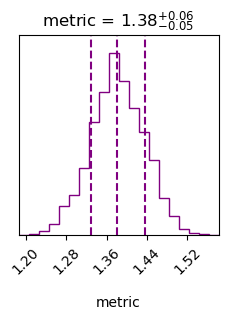

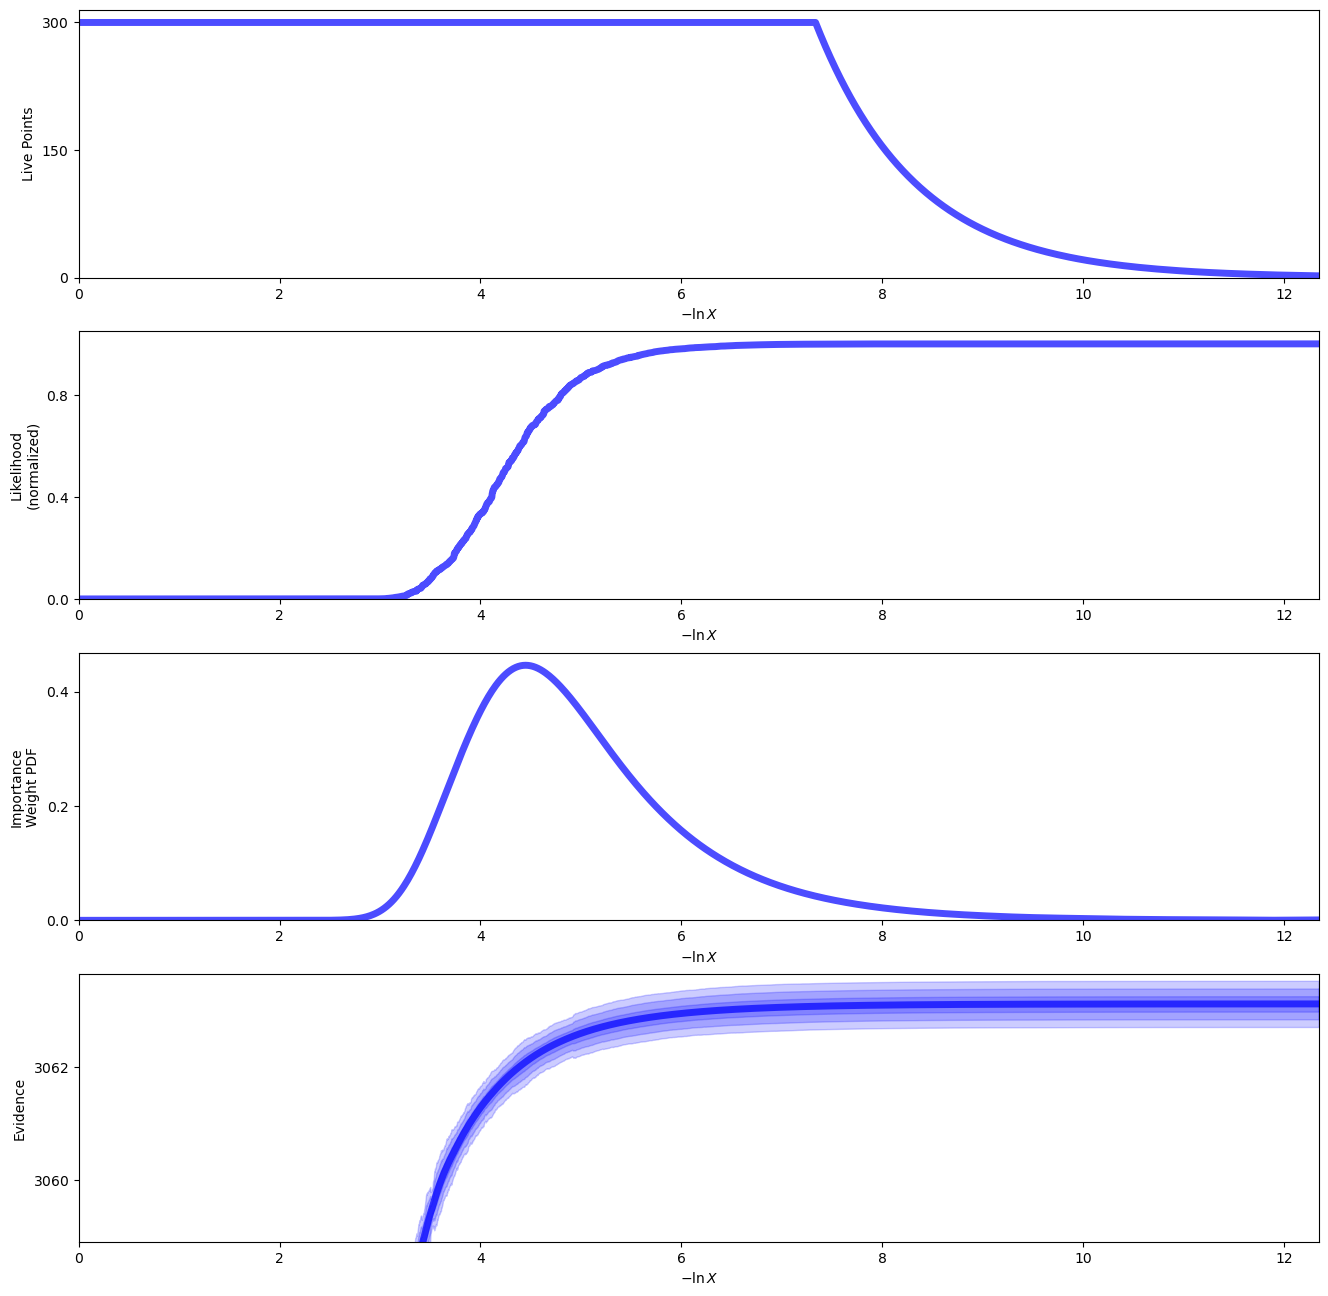

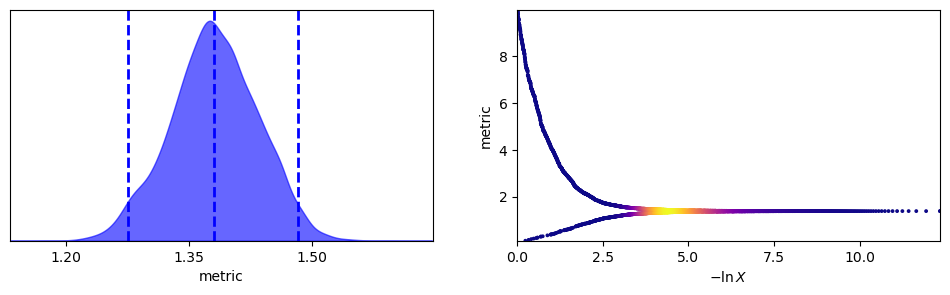

In [14]:
sampler_GP_air.plot()

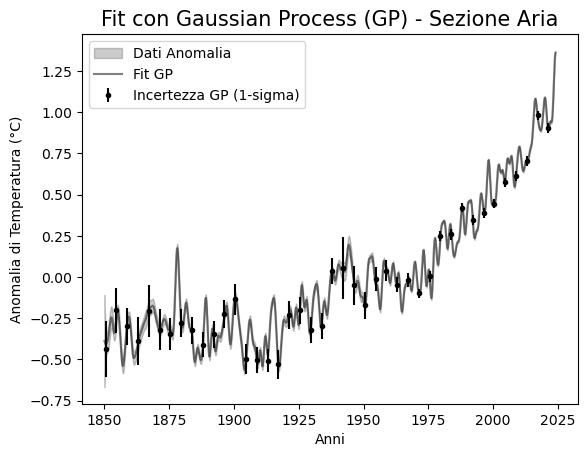

In [15]:
t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088) # Per il grafico (asse X)
t_grid_calc = t_grid_plot - t_start

mean_metric_air = results_GP_air['samples'].mean()
time_train = data_air_masked['time_centered']
anomalies_air = data_air_masked['Annual_Anomaly']
anomalies_unc_air = data_air_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric_air)
res_gp = george.GP(res_kernel)
res_gp.compute(time_train, anomalies_unc_air)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies_air, t_grid_calc, return_var=True)

plt.errorbar(data_air_masked['time_years'][::50], anomalies_air[::50], yerr=anomalies_unc_air[::50], fmt=".k", capsize=0, zorder=0)
plt.fill_between(t_grid_plot, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(t_grid_plot, pred_anomalies, "k", lw=1.5, alpha=0.5)
plt.legend(['Dati Anomalia', 'Fit GP', 'Incertezza GP (1-sigma)'])
plt.xlabel('Anni')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Fit con Gaussian Process (GP) - Sezione Aria', fontsize=15)
plt.show()


### Processi Gaussiani senza trend - Acqua

In [17]:
sampler_GP_water = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood_water, transform=log_prior)
results_GP_water = sampler_GP_water.run(min_num_live_points=300)
sampler_GP_water.print_results()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=3e+03  3.40 [3133.4001..3133.4001]*| it/evals=2349/2747 eff=95.9951% N=300 
[ultranest] Likelihood function evaluations: 2748
[ultranest]   logZ = 3129 +- 0.1219
[ultranest] Effective samples strategy satisfied (ESS = 967.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.12 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.11 bs:0.12 tail:0.03 total:0.13 required:<0.50
[ultranest] done iterating.

logZ = 3128.903 +- 0.249
  single instance: logZ = 3128.903 +- 0.115
  bootstrapped   : logZ = 3128.924 +- 0.247
  tail           : logZ = +- 0.035
insert order U test : converged: True correlation: inf iterations

    metric              : 1.222 │ ▁▁▁ ▁▁▁▁▂▂▂▃▄▄▅▆▆▅▇▇▆▆▆▅▅▄▂▂▂▁▁▁▁▁▁▁▁ │1.666     1.451 +- 0.061



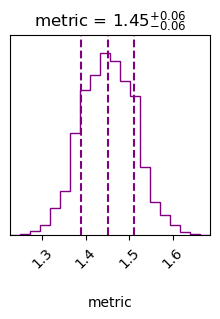

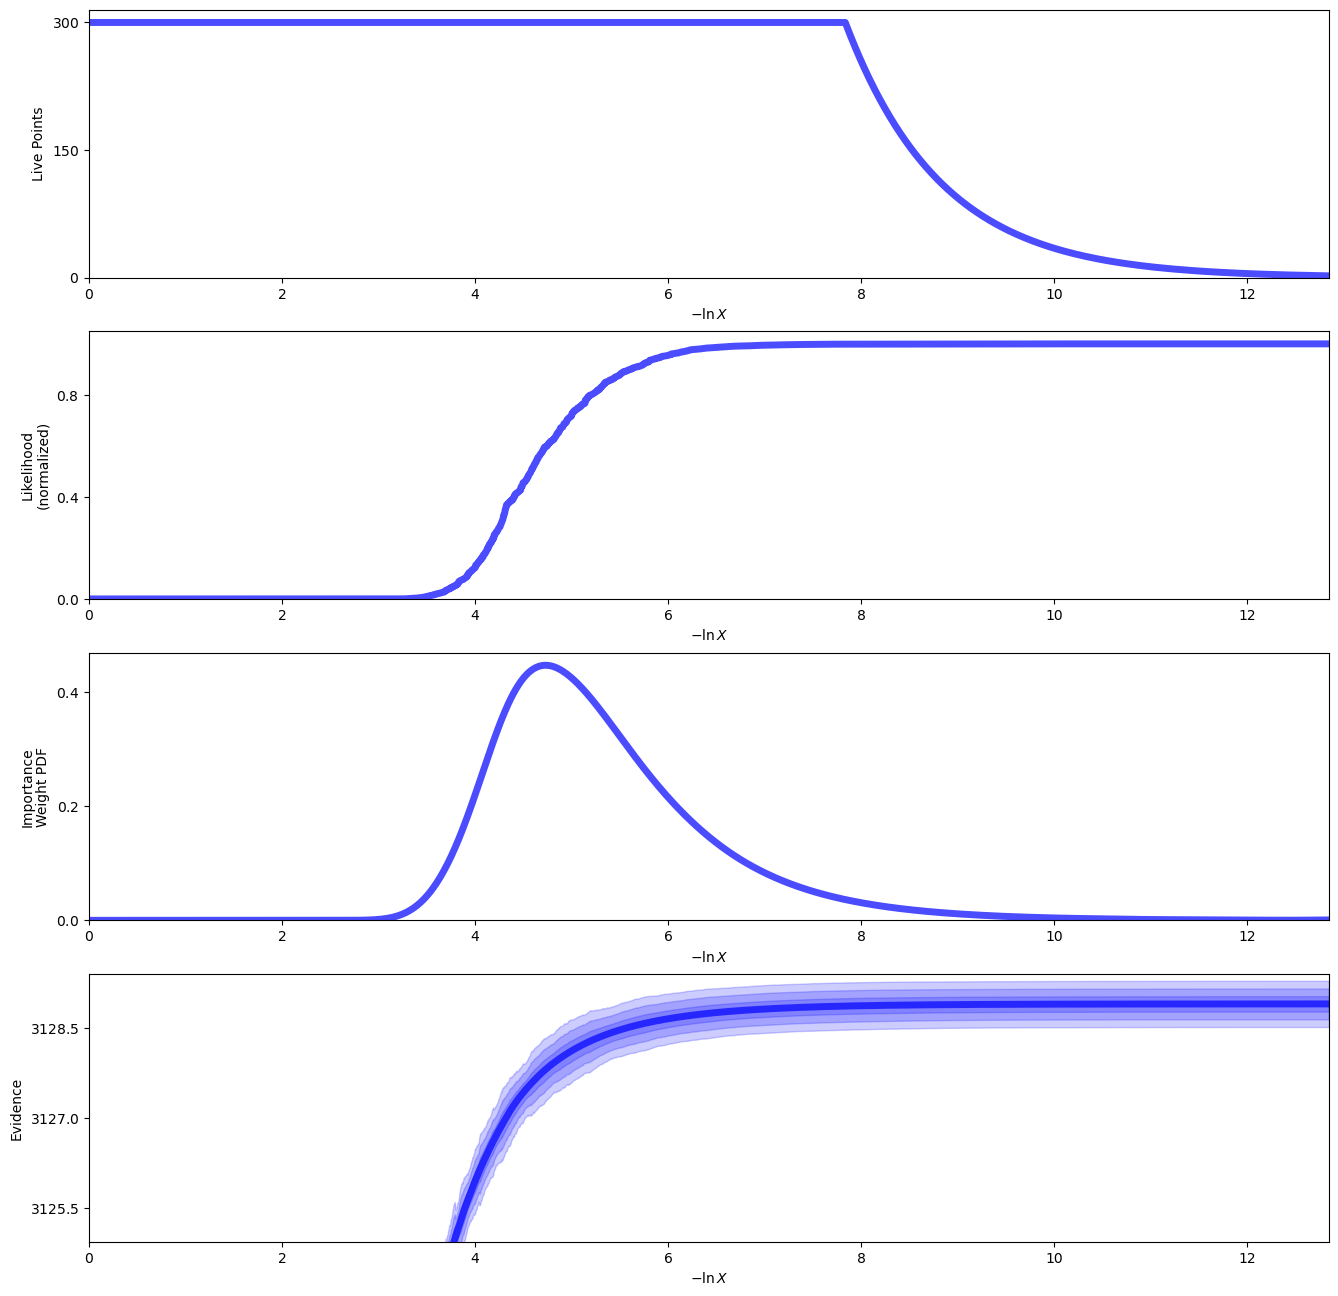

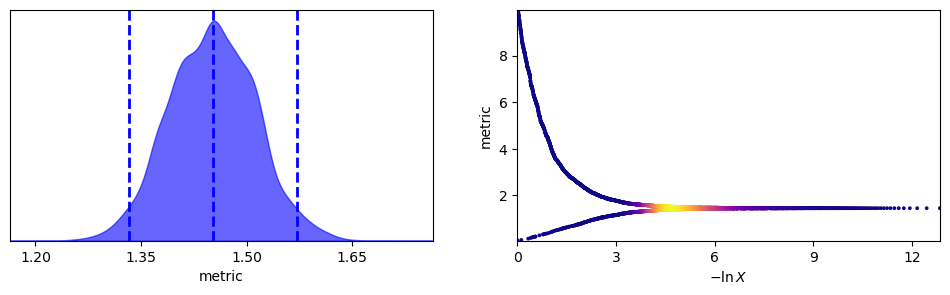

In [18]:
sampler_GP_water.plot()

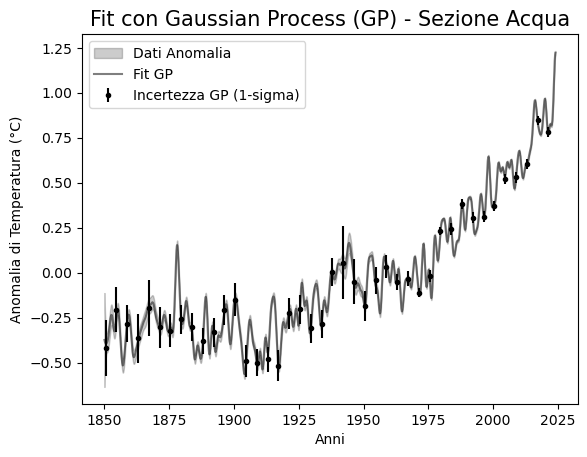

In [19]:
mean_metric_water = results_GP_water['samples'].mean()
time_train = data_water_masked['time_centered']
anomalies_water = data_water_masked['Annual_Anomaly']
anomalies_unc_water = data_water_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric_water)
res_gp = george.GP(res_kernel)
res_gp.compute(time_train, anomalies_unc_water)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies_water, t_grid_calc, return_var=True)

plt.errorbar(data_water_masked['time_years'][::50], anomalies_water[::50], yerr=anomalies_unc_water[::50], fmt=".k", capsize=0, zorder=0)
plt.fill_between(t_grid_plot, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(t_grid_plot, pred_anomalies, "k", lw=1.5, alpha=0.5)
plt.legend(['Dati Anomalia', 'Fit GP', 'Incertezza GP (1-sigma)'])
plt.xlabel('Anni')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Fit con Gaussian Process (GP) - Sezione Acqua', fontsize=15)
plt.show()

### Processi Gaussiani con Trend

In [ ]:
os.environ["OMP_NUM_THREADS"] = "1"

class Exp(Model):
    parameter_names = ("a", "b", "c")
    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c


def prior_exponential_safe(cube):
    params = cube.copy()
    params[:, 0] = cube[:, 0] * 0.4
    params[:, 1] = cube[:, 1] * 0.03
    params[:, 2] = cube[:, 2] * 1.0 - 0.5
    params[:, 3] = cube[:, 3] * 20.0 - 10.0
    params[:, 4] = cube[:, 4] * 20.0 - 15.0

    return params

kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
exp_model = george.GP(kernel=kernel, mean=Exp(a=0.0, b=0.00, c=0.0))
exp_model.compute(data_air_masked['time_centered'][::20], data_air_masked['Annual_Anomaly_Unc'][::20])

def log_likelihood_single(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(data_air_masked['Annual_Anomaly'][::20], quiet=True)


def log_likelihood_vectorized(params_batch):
    return np.array(list(pool.map(log_likelihood_single, params_batch)))

n_cores = 16

pool = Pool(processes=n_cores)

param_names = ['a', 'b', 'c', 'lc', 'metric']

sampler = ReactiveNestedSampler(
    param_names, 
    log_likelihood_vectorized, 
    prior_exponential_safe,
    vectorized=True,
    log_dir='run_gp',
    resume='overwrite'
)

results = sampler.run(min_num_live_points=600)

pool.close()
pool.join()

sampler.print_results()

Process ForkPoolWorker-865:
Exception ignored in: <Finalize object, dead>
Traceback (most recent call last):
  File "/home/ele/anaconda3/lib/python3.13/multiprocessing/util.py", line 216, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/ele/anaconda3/lib/python3.13/multiprocessing/pool.py", line 695, in _terminate_pool
    cls._help_stuff_finish(inqueue, task_handler, len(pool))
  File "/home/ele/anaconda3/lib/python3.13/multiprocessing/pool.py", line 675, in _help_stuff_finish
    inqueue._rlock.acquire()
KeyboardInterrupt: 
Process ForkPoolWorker-862:
Process ForkPoolWorker-864:
Process ForkPoolWorker-859:
Process ForkPoolWorker-868:
Process ForkPoolWorker-861:
Process ForkPoolWorker-858:
Process ForkPoolWorker-863:
Process ForkPoolWorker-866:
Process ForkPoolWorker-860:
Process ForkPoolWorker-854:
Process ForkPoolWorker-856:
Process ForkPoolWorker-857:
Process ForkPoolWorker-853:
Process ForkPoolWorker-867:
Traceback (most recent call last):
Traceback 

In [43]:
import numpy as np
import george
from george import kernels
from george.modeling import Model
from ultranest import ReactiveNestedSampler
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction
import os

os.environ["OMP_NUM_THREADS"] = "1"

# 1. MODELLO DECORRELATO (Risolve le ellissi diagonali)
class Exp(Model):
    parameter_names = ("a", "b", "c")
    def get_value(self, t):
        return self.a * np.exp(self.b * (t-87)) + self.c

def prior_exponential_safe(cube):
    params = cube.copy()
    params[0] = cube[0] * 0.6           # a
    params[1] = cube[1] * 0.06          # b
    params[2] = cube[2] * 3.0 - 0.5     # c
    params[3] = cube[3] * 20.0 - 15.0   # lc
    params[4] = cube[4] * 20.0 - 10.0   
    #params[5] = cube[5] * 6.0 - 8.0
    #params[5] = cube[5] * 12.0 - 12.0

    return params

# 3. KERNEL E DATI
print("Inizializzazione Kernel e Dati...")
#kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
kernel = kernels.ExpSquaredKernel(1.0)
exp_model = george.GP(kernel=kernel, mean=Exp(a=0.0, b=0.00, c=0.0), white_noise=-5, fit_white_noise=True)

t_data = data_air_masked['time_centered'][::20]
y_data = data_air_masked['Annual_Anomaly'][::20]
u_data = data_air_masked['Annual_Anomaly_Unc'][::20]

exp_model.compute(t_data, u_data)

# 4. LIKELIHOOD CON SALVAVITA (Evita il congelamento!)
def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(y_data, quiet=True)

param_names = ['a', 'b', 'c', 'log_metric', 'log_white_noise']

print("Preparazione Sampler...")
sampler = ReactiveNestedSampler(
    param_names, 
    log_likelihood, 
    prior_exponential_safe,
    # log_dir='final3',
    # resume='overwrite'
)


print("Tutto pronto. INIZIO CAMPIONAMENTO!")
results = sampler.run(min_num_live_points=300)

sampler.print_results()

Inizializzazione Kernel e Dati...
Preparazione Sampler...
Tutto pronto. INIZIO CAMPIONAMENTO!
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=7e+01  69.4024..69.4024]*| it/evals=4509/111684 eff=4.0482% N=300 0    0  
[ultranest] Likelihood function evaluations: 111716
[ultranest]   logZ = 59.09 +- 0.08593
[ultranest] Effective samples strategy satisfied (ESS = 1962.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.09, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.09 tail:0.01 total:0.09 required:<0.50
[ultranest] done iterating.

logZ = 59.093 +- 0.213
  single instance: logZ = 59.093 +- 0.158
  bootstrapped   : logZ = 59.094 +- 0.213
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00  │▅▆▇▇▆▆▆▇▆▄▄▆▅▄▅▄▄▅▄▄▃▃▄▃▃▃▂▃▄▂▂▃▃▂▂▂▃▂▂│0.60      0.24 +- 0.16
    b                   : 0.0000│▁▁▁▂▂▂▂▃▃▅▇▇▇▇▇▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁│0.0600    0.0226 +- 0.0099
    c                   : -0.50 │▇▇

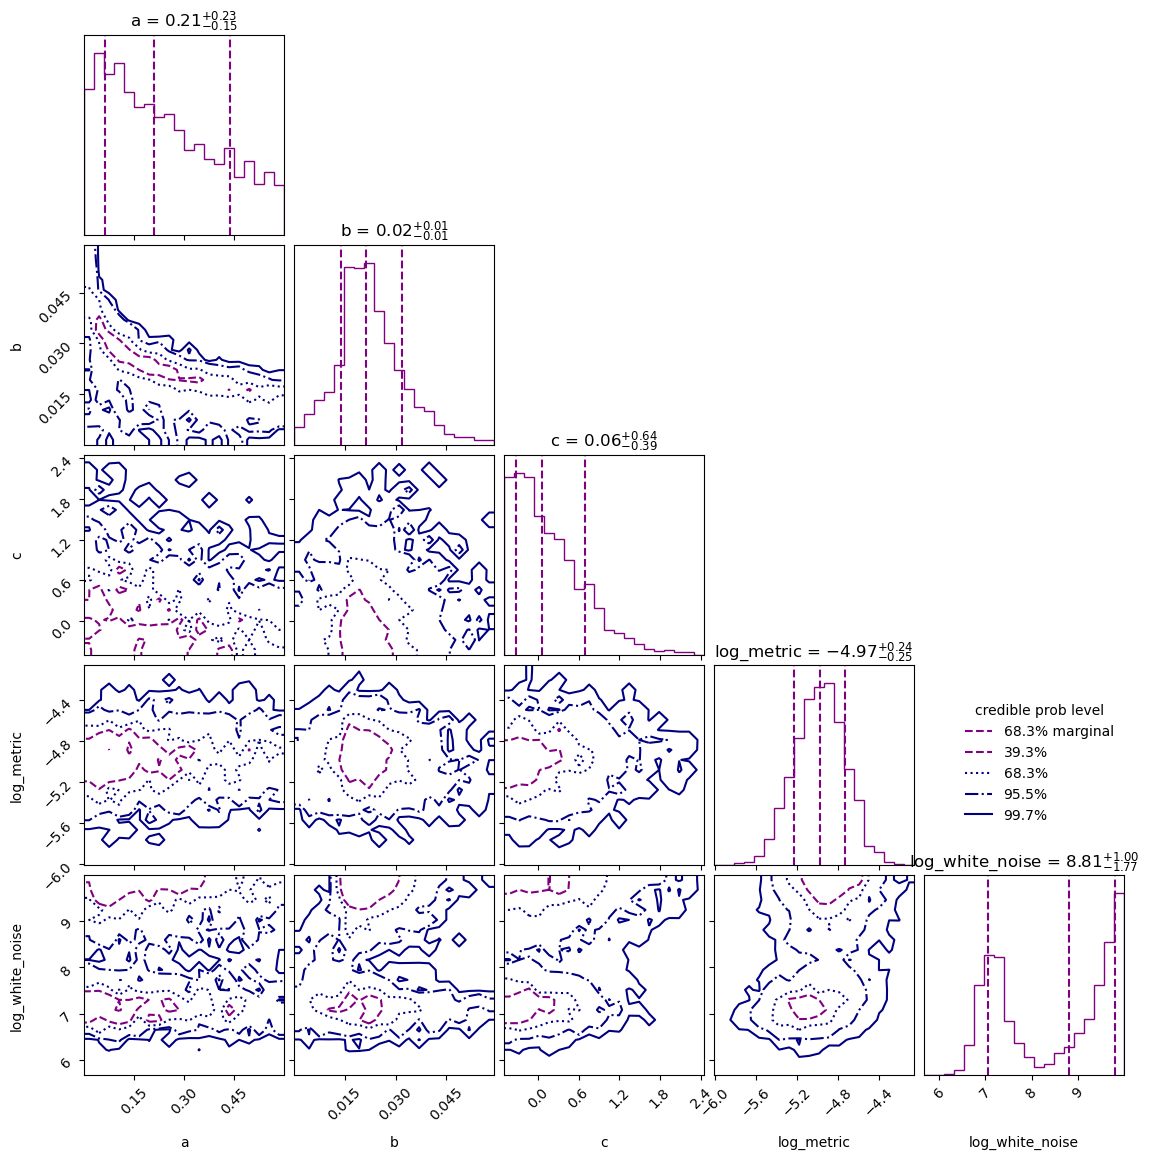

In [44]:
cornerplot(results);